## Intro
In this notebook im going to utilize scikit-learn's <u>Wine</u> and <u>Iris</u> datasets. Using LogisticRegression im going to predict categorical data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
data0 = load_wine()
x = data0.data
y = data0.target
data_wine = pd.DataFrame(np.hstack((x,np.array(y).reshape(-1,1))),columns = data0.feature_names+['target'])
data_wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2.0


In [3]:
data_wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<Figure size 2000x2000 with 0 Axes>

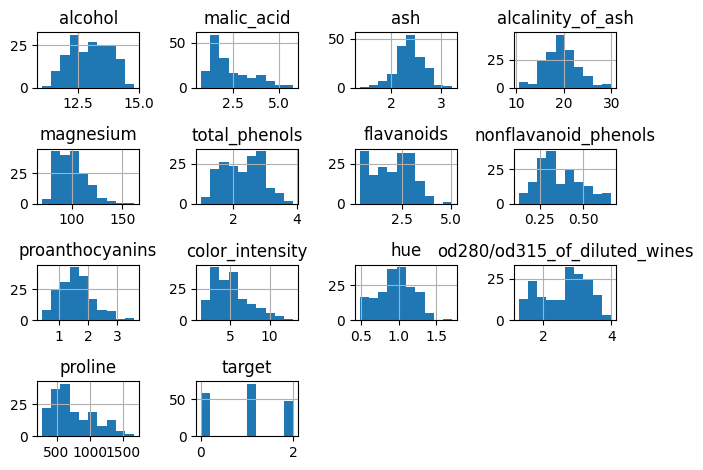

In [4]:
plt.figure(figsize = (20,20))
data_wine.hist()
plt.tight_layout()

In [5]:
model = LogisticRegression()
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 0)
sc = MinMaxScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)
model.fit(x_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
tr = accuracy_score(y_train,model.predict(x_train_sc))
te = accuracy_score(y_test,model.predict(x_test_sc))
print(f"Training Data Scores {tr}")
print(f"Testing Data Scores {te}")


Training Data Scores 0.9859154929577465
Testing Data Scores 1.0


As the model might have predicted on a very informative/easy 20% part of data achieving 100% score, we will perform cross-validation across all the data.

In [7]:
cv = KFold(n_splits = 10, shuffle = True, random_state = 0)
train_scores, test_scores = [], []
for train_index, test_index in cv.split(x):
    model = LogisticRegression()
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    sc = MinMaxScaler()
    x_train_sc = sc.fit_transform(x_train)
    x_test_sc = sc.transform(x_test)
    model.fit(x_train_sc, y_train)
    train_acc = accuracy_score(y_train, model.predict(x_train_sc))
    test_acc = accuracy_score(y_test, model.predict(x_test_sc))

    train_scores.append(train_acc)
    test_scores.append(test_acc)

print("Train accuracy:", train_scores)
print("Test accuracy:", test_scores)

print(f'Training results average: {np.mean(train_scores)}')
print(f'Testing results average: {np.mean(test_scores)}')

Train accuracy: [0.9875, 0.99375, 0.9875, 0.99375, 0.99375, 0.9875, 0.9875, 0.9875, 0.9875776397515528, 0.9875776397515528]
Test accuracy: [1.0, 1.0, 1.0, 0.9444444444444444, 0.9444444444444444, 1.0, 1.0, 1.0, 1.0, 1.0]
Training results average: 0.9893905279503107
Testing results average: 0.9888888888888889


**Iris Prediction**

In [8]:
data1 = load_iris()
X = data1.data
Y = data1.target
data_iris = pd.DataFrame(np.hstack((X,np.array(Y).reshape(-1,1))), columns = data1.feature_names + ['target'])
data_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [9]:
data_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size = 0.25, random_state = 0)
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)
model = LogisticRegression()
model.fit(x_train_sc, y_train)
a1=accuracy_score(y_train, model.predict(x_train_sc))
a2=accuracy_score(y_test, model.predict(x_test_sc))
print(f"Prediciton accuracy on training data: {a1}")
print(f"Prediciton accuracy on testing data: {a2}")

Prediciton accuracy on training data: 0.9732142857142857
Prediciton accuracy on testing data: 0.9736842105263158


In [11]:
kf = KFold(n_splits = 10,shuffle = True, random_state = 0)
test_scores, train_scores = [],[]
for tr_ind, te_ind in kf.split(X):
    model = LogisticRegression()
    x_train, y_train = X[tr_ind], Y[tr_ind]
    x_test, y_test = X[te_ind], Y[te_ind]
    sc = StandardScaler()
    x_train_sc = sc.fit_transform(x_train)
    x_test_sc = sc.transform(x_test)
    model.fit(x_train_sc, y_train)
    test_acc = accuracy_score(y_test, model.predict(x_test_sc))
    train_acc = accuracy_score(y_train, model.predict(x_train_sc))
    test_scores.append(test_acc)
    train_scores.append(train_acc)
print("Traning data prediction accuracy:", train_scores)
print("Testing data prediction accuracy:", test_scores)

print(f'Training results average: {np.mean(train_scores)}')
print(f'Testing results average: {np.mean(test_scores)}')

Traning data prediction accuracy: [0.9629629629629629, 0.9703703703703703, 0.9777777777777777, 0.9777777777777777, 0.9703703703703703, 0.9777777777777777, 0.9703703703703703, 0.9703703703703703, 0.9777777777777777, 0.9777777777777777]
Testing data prediction accuracy: [1.0, 1.0, 0.9333333333333333, 0.8, 1.0, 1.0, 1.0, 1.0, 0.9333333333333333, 0.9333333333333333]
Training results average: 0.9733333333333333
Testing results average: 0.96
